<a href="https://colab.research.google.com/github/chrisBO4630/Machine-Learning-with-Python/blob/main/eigenversuch_MNIST6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trainings eine Bildkalssifizeirungsmodells CNN mit dem Datensatz Fashion-MNIST  

Es es soll ein  Convolutional Neural Network (CNN) verwendet, das in einer sequentiellen Architektur (keras.Sequential) implementiert wurde.

__Spezifische Einordnung__

__Modelltyp:__ Es ist ein klassisches Deep Convolutional Neural Network (DCNN) zur Bildklassifizierung.

__Struktur:__ Ein Feedforward-Modell. Die Daten fließen linear von der Eingabe zur Ausgabe, ohne Rückkopplungen oder parallele Zweige (abgesehen von der internen Sequenz der Data Augmentation).

##Fashion-MNIST

ist ein Datensatz von Zalando-Artikeln, der als direkter Ersatz für den klassischen MNIST-Datensatz (handschriftliche Ziffern) entwickelt wurde. Er dient als Benchmark für Algorithmen des maschinellen Lernens.
Technische Daten

Struktur: 70.000 Graustufenbilder im Format 28×28 Pixel.

Aufteilung: 60.000 Trainingsbilder und 10.000 Testbilder.

Klassen: 10 verschiedene Kategorien von Kleidung und Accessoires.

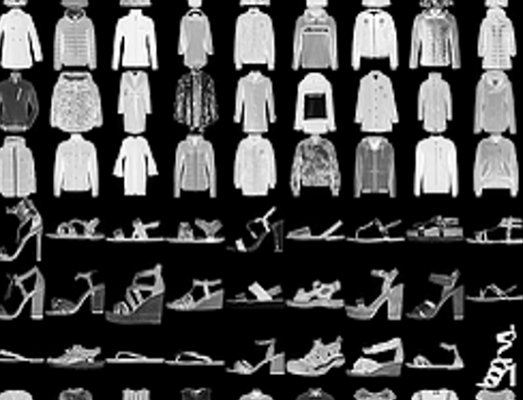

Die 10 Klassen

Die Labels sind als Integer-Werte (0–9) kodiert:
0. T-shirt/top, 1. Trouser, 2. Pullover, 3. Dress, 4. Coat, 5. Sandal, 6. Shirt, 7. Sneaker, 8. Bag, 9. Ankle boot.
Bedeutung

Fashion-MNIST ist komplexer als das Original-MNIST, da die Merkmale (z. B. Texturen von Stoffen) subtiler sind. Es wird häufig genutzt, um Bildklassifizierungsmodelle wie CNNs zu testen, ohne die Rechenlast riesiger Datensätze wie ImageNet zu tragen.

https://www.kaggle.com/datasets/zalando-research/fashionmnist

Weitere gute Hintergrundinformationen finden sich auf :
https://github.com/zalandoresearch/fashion-mnist?tab=readme-ov-file


## Aufgabenstellung

Dieser Programm-Schritt lädt den Datensatz fashion_mnist direkt aus Keras
1) from keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

Für ein CNN:

Pixelwerte von 0...255 auf 0...1 sklieren
x_train = x_train[..., None] / 255.0
x_test = x_test[..., None] / 255.0

Anmerkung:
Die Normalisierung stabiliesiert den Traininigsverlauf. Große Eingabewerte führen sonst oft zu unruhigen Gradienten und erschweren die Optimierung.


.  

## Anmerkungen

Wenn der Prozess der Validierung eingefügt werden soll, dann müssten die Validierungsdaten "manuel" abgespallten werden (mit Slicing oder train_test_split). Die Daten liegen ja eigentlich nur als train und test vor.

Die Bilder liegen als NumPy-Arrays vor. Das kann man sich als riesige CSV-Dateivorstellen, in welcher in den Zellen Ziffern die Bilddaten darstellen.
Um diese Bilder anzuzeigen, geht das nur mit matplotlib.pyplot.imshow()

## geplante Vorgehensweise:

### 1) Bibliotheken importieren: TensorFlow, Keras, Matplotlib, NumPy.

### 2) Daten laden: Nutzung von fashion_mnist.load_data().

### 3) Explorative Datenanalyse: Anzeigen einiger Bilder, um die Skalierung (0–255) und die Labels zu prüfen.

### 4) Daten-Vorverarbeitung: * Normalisierung: Umwandlung der Pixelwerte von [0,255] in das Intervall [0,1] durch Division durch 255.0.

### 5) Reshaping: Sicherstellen, dass die Daten die Form (28,28,1) für das CNN haben.

### 5.5) Validierungs-Split: Manuelles Abspalten von z. B. 5.000 Bildern aus den Trainingsdaten.

### 6) Modell definieren ): Aufbau eines CNN (Sequential-Modells) mit Conv2D, MaxPooling2D, Flatten und Dense.

### 7) Kompilieren: Wahl des Optimierers (z. B. adam) und der Loss-Funktion (sparse_categorical_crossentropy).

### 8) Training: Starten des Trainings mit model.fit() unter Verwendung der Validierungsdaten.

### 9) Auswerten : Prüfung der Performance auf den Testdaten (model.evaluate()).

### 10) Visualisierung : Plotten der Loss-Kurven und Durchführung von Einzelvorhersagen mit model.predict().




## 1. Import der Bibliotheken

In [ ]:
# =========================
# 1. Importieren der Bibliotheken
# =========================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


### 2. Datenladen

In [ ]:
# =========================
# 2. Daten laden
# =========================
# Der Datensatz ist bereitz in der Bibliothek enthalten
from tensorflow.keras.datasets import fashion_mnist

# Laden der Daten durch einen Funktionsaufruf
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

print("Der Datensatz Fashion-MNIST wurde erfolgreich importiert und in den Speicher geladen.")
print(f"Größe der Trainingsbilder: {train_images.shape}")
print(f"Größe der Trainingslabels: {train_labels.shape}")
print(f"Größe der Testbilder: {test_images.shape}")
print(f"Größe der Testlabels: {test_labels.shape}")
print(f"Datentyp der Bilder: {train_images.dtype}")
print(f"Minimale Pixelwert: {np.min(train_images)}")
print(f"Maximale Pixelwert: {np.max(train_images)}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Der Datensatz Fashion-MNIST wurde erfolgreich importiert und in den Speicher geladen.
Größe der Trainingsbilder: (60000, 28, 28)
Größe der Trainingslabels: (60000,)
Größe der Testbilder: (10000, 28, 28)
Größe der Testlabels: (10000,)
Datentyp der Bilder: uint8
Minimale Pixelwert: 0
Maximale Pixelwert: 255


## 3. Explorative Datenanalyse

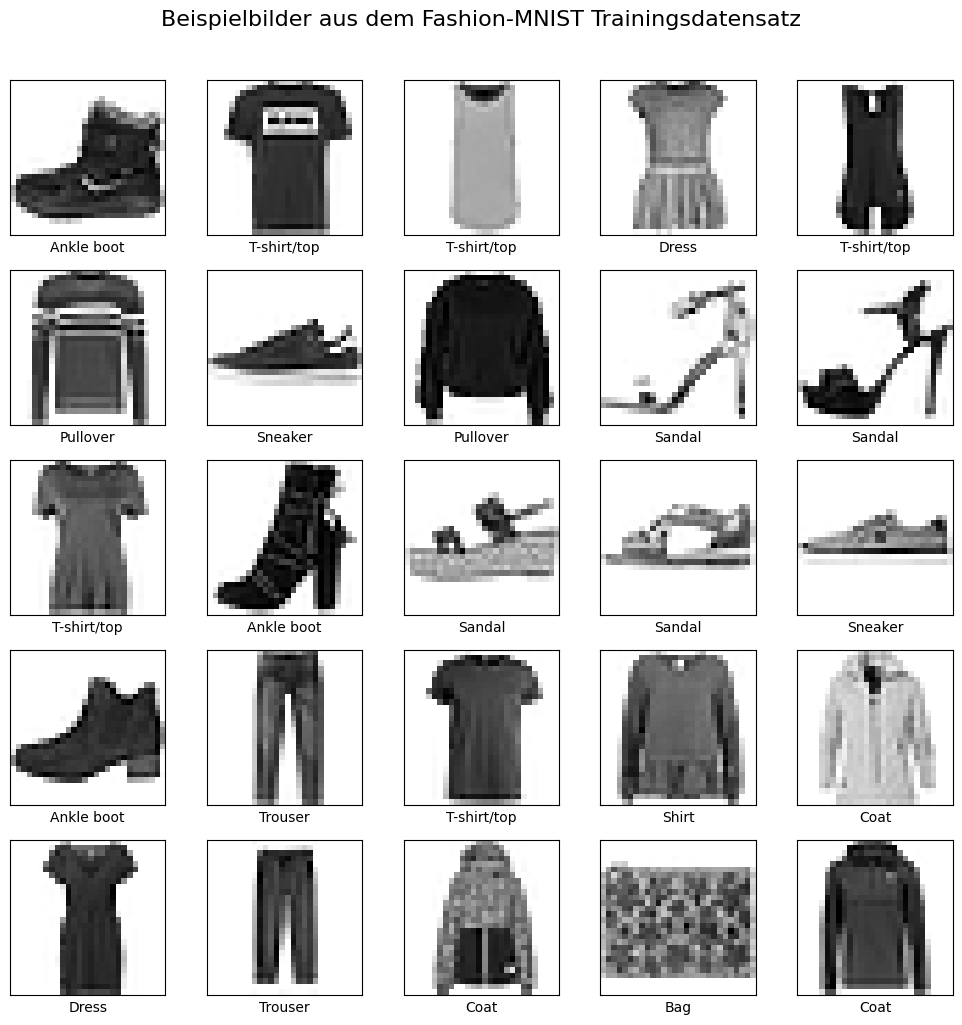

Pixelwerte des ersten Trainingsbildes (min/max): 0 / 255
Shape des ersten Trainingsbildes: (28, 28)


In [ ]:
# Definition der Klassennamen (Labels)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Funktion zum Anzeigen von Bildern
def plot_image(i, predictions_array, true_label, img):
    true_label = true_label[i]
    img = img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    # color = 'blue' if np.argmax(predictions_array) == true_label else 'red' # For predictions later
    plt.xlabel(f"{class_names[true_label]} ({true_label})")

# Anzeigen der ersten 25 Trainingsbilder mit ihren Labels
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1) # Changed from 3,3 to 5,5 to accommodate 25 images
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.suptitle("Beispielbilder aus dem Fashion-MNIST Trainingsdatensatz", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# Überprüfung der Pixelwerte eines Beispielbildes (vor der Normalisierung)
print(f"Pixelwerte des ersten Trainingsbildes (min/max): {np.min(train_images[0])} / {np.max(train_images[0])}")
print(f"Shape des ersten Trainingsbildes: {train_images[0].shape}")

## 4. Daten-Vorverarbeitung

In [ ]:
# Normalisierung der Pixelwerte von [0, 255] auf [0, 1]
train_images = train_images / 255.0
test_images = test_images / 255.0

## 5. Reshaping

In [ ]:
# Reshaping der Bilder, um einen Kanal für das CNN hinzuzufügen (28, 28, 1)
# Sicherstellen, dass die Dimension (Anzahl der Samples, Höhe, Breite, Kanal) ist
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1)
test_images = test_images.reshape(test_images.shape[0], 28, 28, 1)

print(f"Shape der Trainingsbilder nach Normalisierung und Reshaping: {train_images.shape}")
print(f"Shape der Testbilder nach Normalisierung und Reshaping: {test_images.shape}")
print(f"Minimale Pixelwert nach Normalisierung: {np.min(train_images)}")
print(f"Maximale Pixelwert nach Normalisierung: {np.max(train_images)}")

Shape der Trainingsbilder nach Normalisierung und Reshaping: (60000, 28, 28, 1)
Shape der Testbilder nach Normalisierung und Reshaping: (10000, 28, 28, 1)
Minimale Pixelwert nach Normalisierung: 0.0
Maximale Pixelwert nach Normalisierung: 1.0


### 5.5 Validierungs-Split

Vor dem Training des Modells werden 5.000 Bilder und Labels aus dem ursprünglichen Trainingsdatensatz als Validierungsdatensatz abgespalten. Dies ermöglicht es, die Leistung des Modells während des Trainings auf unabhängigen Daten zu überwachen und Overfitting zu erkennen. Der verbleibende Teil wird für das eigentliche Training verwendet.

In [ ]:
# =========================
# 5.5 Validieren
# =========================
# Manuelles Abspalten von 5.000 Bildern und Labels für den Validierungsdatensatz
val_images = train_images[-5000:]
val_labels = train_labels[-5000:]

train_images = train_images[:-5000]
train_labels = train_labels[:-5000]

print(f"Shape der Trainingsbilder nach dem Split: {train_images.shape}")
print(f"Shape der Trainingslabels nach dem Split: {train_labels.shape}")
print(f"Shape der Validierungsbilder nach dem Split: {val_images.shape}")
print(f"Shape der Validierungslabels nach dem Split: {val_labels.shape}")

Shape der Trainingsbilder nach dem Split: (55000, 28, 28, 1)
Shape der Trainingslabels nach dem Split: (55000,)
Shape der Validierungsbilder nach dem Split: (5000, 28, 28, 1)
Shape der Validierungslabels nach dem Split: (5000,)


### 6. Modell definieren

In [ ]:
# =========================
# 6. Modell definieren
# =========================

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax') # 10 Klassen für Fashion-MNIST
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### 7. Kompilieren

In [ ]:
# =========================
# 7. Kompilieren
# =========================

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### 8. Training

In [ ]:
# =========================
# 8. Training
# =========================

history = model.fit(train_images,
                    train_labels,
                    epochs=10, # Anzahl der Trainingsepochen, kann angepasst werden
                    validation_data=(val_images, val_labels)) # Validierungsdaten verwenden

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.8358 - loss: 0.4560 - val_accuracy: 0.8700 - val_loss: 0.3586
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8876 - loss: 0.3066 - val_accuracy: 0.8938 - val_loss: 0.2840
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9042 - loss: 0.2605 - val_accuracy: 0.9006 - val_loss: 0.2660
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9144 - loss: 0.2283 - val_accuracy: 0.9044 - val_loss: 0.2754
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9248 - loss: 0.2027 - val_accuracy: 0.9108 - val_loss: 0.2414
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9330 - loss: 0.1779 - val_accuracy: 0.9070 - val_loss: 0.2495
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9399 - loss: 0.1572 - val_accuracy: 0.9126 - val_loss: 0.2504
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9465 - loss: 0.1396 -

## Trainingszeiten

1) Mit Laufzeitmodell GPU T4 ca. 1 Minute


### 9. Auswertung

In [ ]:
# =========================
# 9. Auswertung
# =========================

loss, accuracy = model.evaluate(test_images, test_labels, verbose=2)
print(f"Test-Loss: {loss:.4f}")
print(f"Test-Genauigkeit: {accuracy*100:.2f}%")

313/313 - 2s - 6ms/step - accuracy: 0.9106 - loss: 0.2883
Test-Loss: 0.2883
Test-Genauigkeit: 91.06%


### 10. Visualisierung

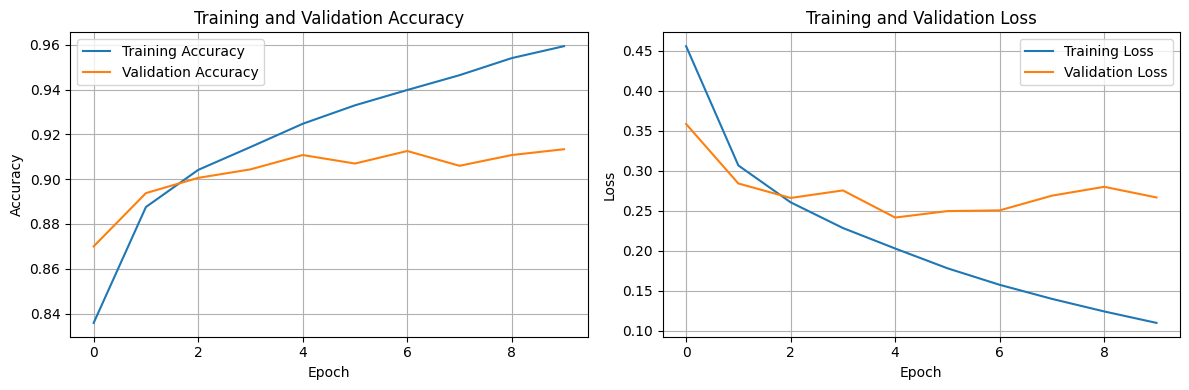

In [ ]:
# =========================
# 10. Visualisierung
# =========================

# Plot der Trainings- und Validierungsgenauigkeit sowie des Losses
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Plot Training und Validierungs-Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot Training und Validierungs-Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history)

### 11. Einzelne Vorhersagen visualisieren

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


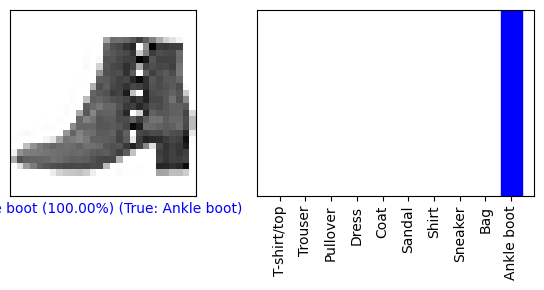

In [ ]:
# Funktion zum Plotten von Vorhersagewahrscheinlichkeiten
def plot_value_array(i, predictions_array, true_label):
    true_label = true_label[i]
    plt.grid(False)
    plt.xticks(range(10), class_names, rotation=90)
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

# Funktion zum Anzeigen von Bildern mit Vorhersagen
def plot_image_with_prediction(i, predictions_array, true_label, img):
    true_label_val = true_label[i]
    img_val = img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img_val.reshape(28, 28), cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label_val else 'red'

    plt.xlabel(f"{class_names[predicted_label]} ({100*np.max(predictions_array):.2f}%) (True: {class_names[true_label_val]})",
               color=color)

# Beispiel für eine Einzelvorhersage
i = np.random.randint(0, len(test_images)) # Wählen Sie einen zufälligen Index aus dem Testdatensatz
img = test_images[i:i+1] # Nehmen Sie ein einzelnes Bild, um die Dimensionen zu erhalten
predictions = model.predict(img)

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image_with_prediction(i, predictions[0], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[0], test_labels)
plt.tight_layout()
plt.show()